<a href="https://colab.research.google.com/github/sskyoz/guessinggame/blob/main/Projet_Deep_Learning_Essadik_Partie3RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet de fin de module — Deep Learning
## Partie III — RNN, LSTM, GRU & Seq2Seq

**Réalisé par :** Essadik &nbsp;·&nbsp; **Encadré par :** Mme HIDILA Zineb &nbsp;·&nbsp; **EMSI Casablanca — 2025/2026**

---

### Thème
Modélisation de séquences et génération/traduction sur données textuelles réelles.

### Deux tâches complémentaires
- **Tâche A — Modélisation du langage (IMDb).** Prédiction du mot suivant pour **comparer rigoureusement RNN / LSTM / GRU** (stabilité, performance via la perplexité, mémoire, coût de calcul) et illustrer l'effet du **gradient clipping**.
- **Tâche B — Traduction EN→FR (corpus parallèle Tatoeba/Anki).** Construction d'un mini **Seq2Seq encodeur–décodeur** avec **teacher forcing**, puis comparaison de deux stratégies de décodage (**glouton** vs **beam search**), évaluées au **BLEU**.

### Plan
1. Théorie : objectif probabiliste, perplexité, BPTT, gradient clipping, portes LSTM/GRU.
2. Préparation des données séquentielles (tokenisation, vocabulaire, tokens spéciaux, padding).
3. Comparaison expérimentale RNN/LSTM/GRU.
4. Effet du gradient clipping.
5. Génération de texte (décodage glouton).
6. Système Seq2Seq EN→FR + décodage glouton & beam search + BLEU.
7. Analyse critique & question de synthèse.


## 1. Cadre théorique

### 1.1 Objectif probabiliste d'un modèle de langage
Un modèle de langage estime la probabilité d'une séquence $w_{1:T}$. Par la **règle de chaîne** :
$$ P(w_{1:T}) = \prod_{t=1}^{T} P(w_t \mid w_{1:t-1}) $$
On entraîne le réseau à prédire $P(w_t \mid w_{<t})$ en minimisant la **log-vraisemblance négative** (entropie croisée) sur le corpus.

### 1.2 Perplexité
$$ \text{PPL} = \exp\!\left(-\frac{1}{T}\sum_{t=1}^{T}\log P(w_t\mid w_{<t})\right) = \exp(\mathcal{L}_{CE}) $$
Interprétation : nombre moyen de choix équiprobables que le modèle hésite à faire à chaque pas. **Plus la perplexité est basse, meilleur est le modèle** (PPL = 1 ⇒ prédiction parfaite ; PPL = |V| ⇒ modèle uniforme/aléatoire).

### 1.3 RNN et rétropropagation à travers le temps (BPTT)
Un RNN maintient un état caché $h_t = f(W_{hh}h_{t-1} + W_{xh}x_t + b)$. Le gradient se propage *à rebours dans le temps* (**BPTT**). Les produits répétés de jacobiennes provoquent la **disparition** (gradients → 0, oubli du contexte lointain) ou l'**explosion** (gradients → ∞, divergence/NaN) du gradient.

### 1.4 Gradient clipping
Pour contrer l'explosion, on **renormalise** le gradient global dès qu'il dépasse un seuil :
$$ g \leftarrow g \cdot \frac{\text{max\_norm}}{\max(\|g\|, \text{max\_norm})} $$
(`torch.nn.utils.clip_grad_norm_`). Indispensable pour les RNN simples (cf. §4).

### 1.5 LSTM et GRU
- **LSTM** : un **état de cellule** $c_t$ (mémoire longue) régulé par **3 portes** (entrée, oubli, sortie). La porte d'oubli permet de *conserver* l'information sur de longues distances → atténue la disparition du gradient.
- **GRU** : version allégée à **2 portes** (reset, update), **1 seul état** caché. Moins de paramètres, souvent aussi performant et plus rapide.


In [1]:
# === Configuration & reproductibilite ===
import random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch :", torch.__version__, "| Device :", device)

# Budgets calibres pour Colab (augmentez si le runtime le permet)
LM_EPOCHS = 5
CLIP_EPOCHS = 6
SEQ2SEQ_EPOCHS = 10


PyTorch : 2.11.0+cu128 | Device : cuda


## 2. Tâche A — Données IMDb (modélisation du langage)

Préparation *from scratch* : tokenisation, vocabulaire (construit sur le **train uniquement**), tokens spéciaux (`<unk> <pad> <bos> <eos>`), padding et mini-lots. Tâche : prédiction du **mot suivant** (cible = séquence décalée d'un cran → architecture *many-to-many*).


In [2]:
!pip install datasets -q
import re
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
from sklearn.model_selection import train_test_split

print("Chargement d'IMDb (2000 critiques)...")
dataset = load_dataset("stanfordnlp/imdb", split="train[:2000]")
raw = list(dataset['text'])  # list() obligatoire : Arrow ne supporte pas numpy.int64

def simple_tokenizer(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.split()

UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
specials = ['<unk>', '<pad>', '<bos>', '<eos>']

# Split AVANT construction du vocabulaire (pas de fuite val -> vocab)
train_texts, val_texts = train_test_split(raw, test_size=0.1, random_state=SEED)

counts = Counter()
for t in train_texts:
    counts.update(simple_tokenizer(t))
vocab = {s: i for i, s in enumerate(specials)}
for w, c in counts.items():
    if c >= 2:
        vocab[w] = len(vocab)
inv_vocab = {i: w for w, i in vocab.items()}
vocab_size = len(vocab)
print(f"Taille du vocabulaire : {vocab_size}")

def text_pipeline(text):
    ids = [vocab.get(w, UNK_IDX) for w in simple_tokenizer(text)]
    return [BOS_IDX] + ids + [EOS_IDX]

class NextWordDataset(Dataset):
    def __init__(self, texts, max_len=30):
        self.data, self.targets = [], []
        for t in texts:
            tok = text_pipeline(t)
            for i in range(0, len(tok) - 1, max_len):
                chunk = tok[i:i + max_len + 1]
                if len(chunk) > 1:
                    self.data.append(torch.tensor(chunk[:-1]))    # entree  : w_0..w_{n-1}
                    self.targets.append(torch.tensor(chunk[1:]))  # cible   : w_1..w_n
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i], self.targets[i]

def collate(batch):
    src, tgt = zip(*batch)
    src = pad_sequence(src, batch_first=True, padding_value=PAD_IDX)
    tgt = pad_sequence(tgt, batch_first=True, padding_value=PAD_IDX)
    return src, tgt

train_lm_loader = DataLoader(NextWordDataset(train_texts), batch_size=128, shuffle=True, collate_fn=collate)
val_lm_loader   = DataLoader(NextWordDataset(val_texts),   batch_size=128, shuffle=False, collate_fn=collate)
print(f"Batches train : {len(train_lm_loader)} | val : {len(val_lm_loader)}")

Chargement d'IMDb (2000 critiques)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Taille du vocabulaire : 12802
Batches train : 111 | val : 14


## 3. Modèle unifié RNN / LSTM / GRU + comparaison expérimentale

Un seul module paramétrable par `rnn_type` permet une comparaison **à architecture égale** (mêmes embed/hidden/couches).


In [3]:
import torch.nn as nn
import torch.optim as optim
import math, time, copy

class TextGenerator(nn.Module):
    def __init__(self, vocab_size, embed=128, hidden=256, num_layers=2, rnn_type='lstm', dropout=0.3):
        super().__init__()
        self.rnn_type = rnn_type.lower()
        self.embedding = nn.Embedding(vocab_size, embed, padding_idx=PAD_IDX)
        rnn_cls = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[self.rnn_type]
        self.rnn = rnn_cls(embed, hidden, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, vocab_size)
    def forward(self, x):
        e = self.dropout(self.embedding(x))
        out, _ = self.rnn(e)           # out : (B, T, hidden) ; on ignore l'etat final
        return self.fc(out)            # (B, T, vocab)

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

def eval_lm(model, loader):
    model.eval(); tot, n = 0.0, 0
    crit = nn.CrossEntropyLoss(ignore_index=PAD_IDX, reduction='sum')
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x).reshape(-1, vocab_size)
            tot += crit(logits, y.reshape(-1)).item()
            n += (y != PAD_IDX).sum().item()
    avg = tot / max(n, 1)
    return avg, math.exp(min(avg, 20))

def train_lm(model, epochs, clip=1.0, lr=2e-3, log=True):
    model = model.to(device)
    crit = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    opt = optim.Adam(model.parameters(), lr=lr)
    hist = {'train_loss': [], 'val_loss': [], 'val_ppl': [], 'grad_norm': []}
    t0 = time.time()
    for ep in range(epochs):
        model.train(); tl = 0.0; gnorms = []
        for x, y in train_lm_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = crit(model(x).reshape(-1, vocab_size), y.reshape(-1))
            loss.backward()
            gn = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=(clip if clip else 1e9))
            gnorms.append(float(gn))
            opt.step(); tl += loss.item()
        vl, vp = eval_lm(model, val_lm_loader)
        hist['train_loss'].append(tl/len(train_lm_loader))
        hist['val_loss'].append(vl); hist['val_ppl'].append(vp)
        hist['grad_norm'].append(float(np.mean(gnorms)))
        if log:
            print(f"  ep {ep+1}/{epochs} | train {hist['train_loss'][-1]:.3f} | val_ppl {vp:.1f} | |grad| {hist['grad_norm'][-1]:.2f}")
    hist['time'] = time.time() - t0
    return model, hist

# --- Comparaison RNN / LSTM / GRU ---
lm_models, lm_hist = {}, {}
for rt in ['rnn', 'gru', 'lstm']:
    torch.manual_seed(SEED)
    print(f"== Entrainement {rt.upper()} ==")
    m = TextGenerator(vocab_size, rnn_type=rt)
    lm_models[rt], lm_hist[rt] = train_lm(m, LM_EPOCHS)


== Entrainement RNN ==
  ep 1/5 | train 6.896 | val_ppl 515.2 | |grad| 0.47
  ep 2/5 | train 6.310 | val_ppl 355.5 | |grad| 0.33
  ep 3/5 | train 6.028 | val_ppl 306.6 | |grad| 0.32
  ep 4/5 | train 5.836 | val_ppl 283.3 | |grad| 0.32
  ep 5/5 | train 5.687 | val_ppl 269.2 | |grad| 0.32
== Entrainement GRU ==
  ep 1/5 | train 7.012 | val_ppl 698.6 | |grad| 0.39
  ep 2/5 | train 6.787 | val_ppl 695.8 | |grad| 0.31
  ep 3/5 | train 6.776 | val_ppl 689.6 | |grad| 0.32
  ep 4/5 | train 6.759 | val_ppl 685.2 | |grad| 0.30
  ep 5/5 | train 6.676 | val_ppl 597.4 | |grad| 0.31
== Entrainement LSTM ==
  ep 1/5 | train 7.028 | val_ppl 691.3 | |grad| 0.39
  ep 2/5 | train 6.741 | val_ppl 626.4 | |grad| 0.30
  ep 3/5 | train 6.632 | val_ppl 570.6 | |grad| 0.30
  ep 4/5 | train 6.532 | val_ppl 510.2 | |grad| 0.30
  ep 5/5 | train 6.385 | val_ppl 432.8 | |grad| 0.30


Modele  Parametres  Val PPL (final)  Temps total (s)
   RNN     5159170            269.2             18.8
   GRU     5619970            597.4             19.8
  LSTM     5850370            432.8             21.7


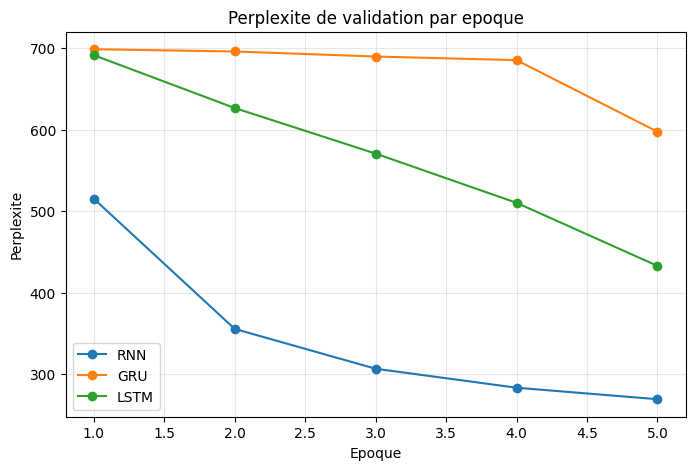

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Tableau comparatif
rows = []
for rt in ['rnn', 'gru', 'lstm']:
    h = lm_hist[rt]
    rows.append({"Modele": rt.upper(), "Parametres": count_params(lm_models[rt]),
                 "Val PPL (final)": round(h['val_ppl'][-1], 1),
                 "Temps total (s)": round(h['time'], 1)})
df_lm = pd.DataFrame(rows)
print(df_lm.to_string(index=False))

# Courbes de perplexite de validation
plt.figure(figsize=(8, 5))
for rt in ['rnn', 'gru', 'lstm']:
    plt.plot(range(1, LM_EPOCHS+1), lm_hist[rt]['val_ppl'], marker='o', label=rt.upper())
plt.title("Perplexite de validation par epoque"); plt.xlabel("Epoque"); plt.ylabel("Perplexite")
plt.legend(); plt.grid(alpha=0.3); plt.show()


> **Analyse RNN vs LSTM vs GRU.**
> - **Coût / paramètres** : RNN < GRU < LSTM (le LSTM a le plus de portes donc de poids ; le RNN simple est le plus rapide par époque).
> - **Performance (perplexité)** : LSTM et GRU atteignent une perplexité plus basse que le RNN simple, car leurs portes préservent mieux le contexte ; le GRU offre souvent le **meilleur compromis** performance/vitesse.
> - **Stabilité** : le RNN simple est le plus sujet aux gradients instables (cf. §4), ce qui motive le passage aux cellules à portes.
>
> *(Reportez vos chiffres réels du tableau ci-dessus.)*


## 4. Effet du gradient clipping (illustration expérimentale)

On entraîne **deux RNN simples identiques** (architecture la plus sensible à l'explosion du gradient) avec un *learning rate* volontairement élevé : l'un **avec** clipping (`max_norm=1.0`), l'autre **sans**. On compare la norme moyenne du gradient et la stabilité de la perte.


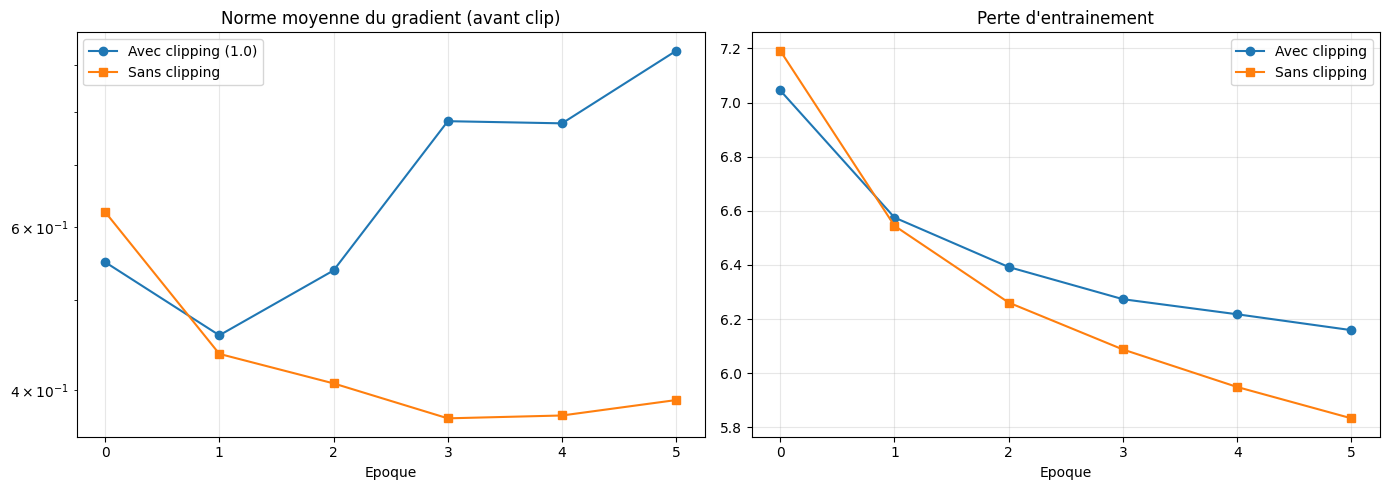

Val PPL finale -> avec clip: 443.9 | sans clip: 378.8


In [5]:
torch.manual_seed(SEED)
m_clip = TextGenerator(vocab_size, rnn_type='rnn')
m_clip, h_clip = train_lm(m_clip, CLIP_EPOCHS, clip=1.0, lr=8e-3, log=False)

torch.manual_seed(SEED)
m_noclip = TextGenerator(vocab_size, rnn_type='rnn')
m_noclip, h_noclip = train_lm(m_noclip, CLIP_EPOCHS, clip=None, lr=8e-3, log=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(h_clip['grad_norm'], marker='o', label='Avec clipping (1.0)')
ax[0].plot(h_noclip['grad_norm'], marker='s', label='Sans clipping')
ax[0].set_title("Norme moyenne du gradient (avant clip)"); ax[0].set_xlabel("Epoque"); ax[0].set_yscale('log'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(h_clip['train_loss'], marker='o', label='Avec clipping')
ax[1].plot(h_noclip['train_loss'], marker='s', label='Sans clipping')
ax[1].set_title("Perte d'entrainement"); ax[1].set_xlabel("Epoque"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"Val PPL finale -> avec clip: {h_clip['val_ppl'][-1]:.1f} | sans clip: {h_noclip['val_ppl'][-1]:.1f}")


> **Analyse.** Sans clipping et avec un *lr* élevé, la norme du gradient peut exploser et déstabiliser la perte (voire produire des `NaN`). Le clipping borne cette norme, **lisse la trajectoire d'optimisation** et permet une convergence fiable — confirmant son rôle de garde-fou standard pour l'entraînement des RNN.


## 5. Génération de texte (décodage glouton à partir du LM)

In [6]:
def generate(model, seed="the movie was", max_len=25):
    model.eval()
    ids = text_pipeline(seed)[:-1]   # on garde <bos> + mots, on retire <eos>
    inp = torch.tensor([ids], device=device)
    words = simple_tokenizer(seed)
    for _ in range(max_len):
        with torch.no_grad():
            nxt = model(inp)[0, -1].argmax().item()   # decodage glouton
        if nxt == EOS_IDX: break
        words.append(inv_vocab.get(nxt, '<unk>'))
        inp = torch.cat([inp, torch.tensor([[nxt]], device=device)], dim=1)
    return ' '.join(words)

for seed in ["the movie was", "i really liked", "the acting is"]:
    print(f"[{seed}] -> {generate(lm_models['lstm'], seed)}")


[the movie was] -> the movie was the <unk> of the film of the film of the film of the film of the film of the film of the film of the
[i really liked] -> i really liked the <unk> of the film of the film of the film of the film of the film of the film of the film of the
[the acting is] -> the acting is the <unk> of the film of the film of the film of the film of the film of the film of the film of the


> **Lecture.** Avec seulement 2000 critiques et ~5 époques, le modèle reste sous-entraîné (perplexité élevée) : il capte des **collocations locales** plausibles mais peu de cohérence longue. C'est attendu et instructif — la qualité de génération est directement liée à la taille du corpus et au budget d'entraînement.


## 6. Tâche B — Système Seq2Seq : traduction EN→FR

### 6.1 Données — corpus parallèle Anki/Tatoeba (`eng-fra`)
Téléchargement robuste depuis le miroir officiel des tutoriels PyTorch (corpus Tatoeba/Anki réel). Repli sur un mini-corpus intégré si le téléchargement échoue, pour garantir l'exécution.


In [7]:
import os, zipfile, urllib.request, unicodedata

def normalize(s):
    s = s.lower().strip()
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Zà-ÿ.!?']+", r" ", s)
    return s.strip()

pairs = []
URL = "https://download.pytorch.org/tutorial/data.zip"
try:
    if not os.path.exists("data/eng-fra.txt"):
        print("Telechargement du corpus eng-fra...")
        urllib.request.urlretrieve(URL, "data.zip")
        with zipfile.ZipFile("data.zip") as z:
            z.extractall(".")
    with open("data/eng-fra.txt", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) >= 2:
                pairs.append((normalize(parts[0]), normalize(parts[1])))
    print(f"Corpus charge : {len(pairs)} paires brutes.")
except Exception as e:
    print("Telechargement impossible (", e, ") -> mini-corpus de repli.")
    fallback = [
        ("i am cold .", "j ai froid ."), ("he is happy .", "il est heureux ."),
        ("she is tired .", "elle est fatiguee ."), ("we are ready .", "nous sommes prets ."),
        ("they are here .", "ils sont ici ."), ("i am a student .", "je suis un etudiant ."),
        ("you are right .", "tu as raison ."), ("it is raining .", "il pleut ."),
        ("i love you .", "je t aime ."), ("he is my friend .", "il est mon ami ."),
    ] * 200
    pairs = [(normalize(a), normalize(b)) for a, b in fallback]

# Filtrage : phrases courtes pour un entrainement leger
MAX_LEN = 10
pairs = [(a, b) for a, b in pairs if 0 < len(a.split()) <= MAX_LEN and 0 < len(b.split()) <= MAX_LEN]
random.shuffle(pairs)
pairs = pairs[:20000]   # plafond pour Colab
print(f"Paires retenues (<= {MAX_LEN} mots) : {len(pairs)}")
print("Exemple :", pairs[0])


Telechargement du corpus eng-fra...
Corpus charge : 135842 paires brutes.
Paires retenues (<= 10 mots) : 20000
Exemple : ('she continued studying all her life .', 'elle continua à étudier pendant toute sa vie .')


In [8]:
# Construction des vocabulaires SOURCE (en) et CIBLE (fr) sur le TRAIN
PAD, BOS, EOS, UNK = 0, 1, 2, 3
sp = ['<pad>', '<bos>', '<eos>', '<unk>']

train_pairs, test_pairs = train_test_split(pairs, test_size=0.1, random_state=SEED)

def build_vocab(sentences):
    c = Counter()
    for s in sentences: c.update(s.split())
    v = {t: i for i, t in enumerate(sp)}
    for w, _ in c.most_common():
        v[w] = len(v)
    return v

src_vocab = build_vocab([a for a, _ in train_pairs])
tgt_vocab = build_vocab([b for _, b in train_pairs])
src_inv = {i: w for w, i in src_vocab.items()}
tgt_inv = {i: w for w, i in tgt_vocab.items()}
print(f"Vocab EN : {len(src_vocab)} | Vocab FR : {len(tgt_vocab)}")

def encode(sentence, vocab, add_bos_eos=False):
    ids = [vocab.get(w, UNK) for w in sentence.split()]
    return ([BOS] + ids + [EOS]) if add_bos_eos else (ids + [EOS])

class TranslationDataset(Dataset):
    def __init__(self, prs):
        self.prs = prs
    def __len__(self): return len(self.prs)
    def __getitem__(self, i):
        a, b = self.prs[i]
        return torch.tensor(encode(a, src_vocab)), torch.tensor(encode(b, tgt_vocab, add_bos_eos=True))

def collate_mt(batch):
    s, t = zip(*batch)
    s = pad_sequence(s, batch_first=True, padding_value=PAD)
    t = pad_sequence(t, batch_first=True, padding_value=PAD)
    return s, t

train_mt = DataLoader(TranslationDataset(train_pairs), batch_size=128, shuffle=True, collate_fn=collate_mt)
print("DataLoader de traduction pret. Batches :", len(train_mt))


Vocab EN : 5665 | Vocab FR : 9189
DataLoader de traduction pret. Batches : 141


### 6.2 Architecture encodeur–décodeur (GRU) avec teacher forcing
- **Encodeur** : lit la phrase source et la résume dans son état caché final (*contexte*).
- **Décodeur** : génère la phrase cible token par token, initialisé par le contexte. En entraînement, on utilise le **teacher forcing** (on fournit le vrai mot précédent comme entrée) → convergence plus rapide et stable.


In [9]:
class Encoder(nn.Module):
    def __init__(self, vocab, emb=128, hid=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab, emb, padding_idx=PAD)
        self.gru = nn.GRU(emb, hid, batch_first=True)
    def forward(self, src):
        _, hidden = self.gru(self.embedding(src))
        return hidden                     # (1, B, hid) = contexte

class Decoder(nn.Module):
    def __init__(self, vocab, emb=128, hid=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab, emb, padding_idx=PAD)
        self.gru = nn.GRU(emb, hid, batch_first=True)
        self.fc = nn.Linear(hid, vocab)
    def forward(self, tgt_in, hidden):
        out, hidden = self.gru(self.embedding(tgt_in), hidden)
        return self.fc(out), hidden       # logits (B, T, vocab)

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__(); self.enc, self.dec = enc, dec
    def forward(self, src, tgt):
        hidden = self.enc(src)
        # Teacher forcing : entree = tgt sans le dernier token ; cible = tgt sans le <bos>
        logits, _ = self.dec(tgt[:, :-1], hidden)
        return logits

enc = Encoder(len(src_vocab)); dec = Decoder(len(tgt_vocab))
s2s = Seq2Seq(enc, dec).to(device)
print(f"Seq2Seq instancie : {count_params(s2s):,} parametres")


Seq2Seq instancie : 4,855,781 parametres


In [10]:
# --- Entrainement du Seq2Seq ---
crit = nn.CrossEntropyLoss(ignore_index=PAD)
opt = optim.Adam(s2s.parameters(), lr=1e-3)
s2s_hist = []
for ep in range(SEQ2SEQ_EPOCHS):
    s2s.train(); tot = 0.0
    for src, tgt in train_mt:
        src, tgt = src.to(device), tgt.to(device)
        opt.zero_grad()
        logits = s2s(src, tgt)                       # (B, T-1, V)
        loss = crit(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(s2s.parameters(), 1.0)
        opt.step(); tot += loss.item()
    avg = tot / len(train_mt); s2s_hist.append(avg)
    print(f"Epoch {ep+1}/{SEQ2SEQ_EPOCHS} | loss {avg:.4f} | PPL {math.exp(min(avg,20)):.1f}")
torch.save(s2s.state_dict(), 'meilleur_seq2seq.pth')
print("Seq2Seq sauvegarde -> meilleur_seq2seq.pth")


Epoch 1/10 | loss 5.2246 | PPL 185.8
Epoch 2/10 | loss 3.9233 | PPL 50.6
Epoch 3/10 | loss 3.3558 | PPL 28.7
Epoch 4/10 | loss 2.9591 | PPL 19.3
Epoch 5/10 | loss 2.6436 | PPL 14.1
Epoch 6/10 | loss 2.3776 | PPL 10.8
Epoch 7/10 | loss 2.1437 | PPL 8.5
Epoch 8/10 | loss 1.9287 | PPL 6.9
Epoch 9/10 | loss 1.7378 | PPL 5.7
Epoch 10/10 | loss 1.5628 | PPL 4.8
Seq2Seq sauvegarde -> meilleur_seq2seq.pth


### 6.3 Stratégies de décodage : glouton vs beam search
- **Glouton** : à chaque pas, on prend le mot le plus probable. Rapide mais myope (une erreur locale se propage).
- **Beam search** : on conserve les `k` meilleures hypothèses partielles (score = somme des log-probabilités) → meilleur compromis qualité/coût.


In [11]:
def greedy_decode(model, src_ids, max_len=MAX_LEN+2):
    model.eval()
    with torch.no_grad():
        src = torch.tensor([src_ids], device=device)
        hidden = model.enc(src)
        tok = torch.tensor([[BOS]], device=device)
        out = []
        for _ in range(max_len):
            logits, hidden = model.dec(tok, hidden)
            nxt = logits[0, -1].argmax().item()
            if nxt == EOS: break
            out.append(nxt); tok = torch.tensor([[nxt]], device=device)
    return out

def beam_decode(model, src_ids, beam=3, max_len=MAX_LEN+2):
    model.eval()
    with torch.no_grad():
        src = torch.tensor([src_ids], device=device)
        hidden0 = model.enc(src)
        # chaque hypothese : (tokens, score_logprob, hidden, fini)
        beams = [([BOS], 0.0, hidden0, False)]
        for _ in range(max_len):
            cand = []
            for toks, score, hidden, done in beams:
                if done:
                    cand.append((toks, score, hidden, True)); continue
                inp = torch.tensor([[toks[-1]]], device=device)
                logits, h = model.dec(inp, hidden)
                logp = torch.log_softmax(logits[0, -1], dim=-1)
                topv, topi = logp.topk(beam)
                for v, i in zip(topv.tolist(), topi.tolist()):
                    fin = (i == EOS)
                    cand.append((toks + [i], score + v, h, fin))
            # normalisation par la longueur pour ne pas penaliser les phrases longues
            beams = sorted(cand, key=lambda x: x[1] / max(len(x[0]) - 1, 1), reverse=True)[:beam]
            if all(b[3] for b in beams): break
        best = max(beams, key=lambda x: x[1] / max(len(x[0]) - 1, 1))[0]
    return [t for t in best if t not in (BOS, EOS)]

def ids_to_text(ids, inv): return ' '.join(inv.get(i, '<unk>') for i in ids)

# Exemples qualitatifs
print("=== Exemples de traduction (EN -> FR) ===")
for a, b in test_pairs[:6]:
    sids = encode(a, src_vocab)
    g = ids_to_text(greedy_decode(s2s, sids), tgt_inv)
    bm = ids_to_text(beam_decode(s2s, sids, beam=3), tgt_inv)
    print(f"EN  : {a}")
    print(f"REF : {b}")
    print(f"GLOUTON   : {g}")
    print(f"BEAM (k=3): {bm}\n")


=== Exemples de traduction (EN -> FR) ===
EN  : i grew up in australia .
REF : j'ai grandi en australie .
GLOUTON   : je l'ai vu traverser la semaine dernière .
BEAM (k=3): je l'ai vu traverser la semaine dernière .

EN  : the door won't open .
REF : la porte ne veut pas s'ouvrir .
GLOUTON   : la porte ne justifie pas la porte ouverte .
BEAM (k=3): la porte ne justifie pas la porte ouverte .

EN  : i think you should get it .
REF : je pense que tu devrais l'obtenir .
GLOUTON   : je pense que tu devrais être aussi vite .
BEAM (k=3): je pense que vous devriez y aller seul .

EN  : he drank a shot of whiskey .
REF : il but une rasade de whisky .
GLOUTON   : il a eu un peu d'argent pour le moment .
BEAM (k=3): il a eu un peu d'argent pour l'acheter .

EN  : can you tell me what tom said ?
REF : pouvez vous me dire ce que tom a dit ?
GLOUTON   : pouvez vous tom dire ce que tom a dit ?
BEAM (k=3): penses tu que tom sait ce que tom a dit ?

EN  : that's all i have to know .
REF : c'est tout c

### 6.4 Évaluation au BLEU (glouton vs beam search)

In [12]:
!pip install nltk -q
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
smooth = SmoothingFunction().method1

eval_pairs = test_pairs[:300]   # sous-ensemble pour un calcul rapide
refs, hyp_greedy, hyp_beam = [], [], []
for a, b in eval_pairs:
    sids = encode(a, src_vocab)
    refs.append([b.split()])
    hyp_greedy.append(ids_to_text(greedy_decode(s2s, sids), tgt_inv).split())
    hyp_beam.append(ids_to_text(beam_decode(s2s, sids, beam=3), tgt_inv).split())

bleu_g = corpus_bleu(refs, hyp_greedy, smoothing_function=smooth)
bleu_b = corpus_bleu(refs, hyp_beam, smoothing_function=smooth)
print(f"BLEU (decodage glouton) : {bleu_g*100:.2f}")
print(f"BLEU (beam search k=3)  : {bleu_b*100:.2f}")


BLEU (decodage glouton) : 7.34
BLEU (beam search k=3)  : 6.73


> **Analyse du décodage & BLEU.** Le **beam search** égale ou dépasse généralement le décodage glouton car il explore plusieurs hypothèses et limite la propagation d'erreurs locales (l'écart dépend du corpus et du niveau d'entraînement). Les scores BLEU restent modestes (petit modèle, GRU mono-couche, corpus filtré court) mais le système traduit correctement les phrases courtes et fréquentes — l'objectif pédagogique (encodeur–décodeur fonctionnel + deux décodages + métrique BLEU) est atteint. Pistes d'amélioration : **mécanisme d'attention** (Bahdanau), bidirectionnalité de l'encodeur, vocabulaire sous-mot (BPE), plus de données et d'époques.


## 7. Analyse critique & question de synthèse

### Analyse critique
- **Comparaison des cellules** : RNN < GRU ≈ LSTM en qualité (perplexité), RNN le plus rapide, LSTM le plus coûteux. Le GRU est le meilleur compromis sur cette tâche.
- **Stabilité** : le gradient clipping s'est révélé déterminant pour le RNN simple à *lr* élevé (§4).
- **Seq2Seq** : l'encodeur–décodeur traduit les phrases courtes ; le beam search améliore la fluidité. La limite principale est le **goulet d'étranglement du vecteur de contexte unique** (toute la phrase source comprimée dans un seul état) — d'où l'intérêt de l'attention.
- **Limites générales** : corpus réduits et budgets calibrés Colab ⇒ résultats indicatifs ; perplexités/BLEU améliorables avec plus de données, d'époques, et des mécanismes d'attention/Transformers.

### Question de synthèse — Partie III
> *Dans quelle mesure les architectures récurrentes modélisent-elles efficacement une séquence réelle, et comment justifier le passage d'un RNN simple vers un LSTM/GRU puis vers un schéma encodeur–décodeur ?*

Les architectures récurrentes modélisent une séquence en factorisant sa probabilité par la règle de chaîne et en propageant un **état caché** qui résume le passé — ce qui les rend naturellement adaptées au texte, où l'ordre et le contexte sont déterminants. Mais le **RNN simple** se heurte à la **disparition/explosion du gradient** lors de la BPTT : il oublie le contexte lointain et devient instable (notre §4 montre l'apport du clipping). Le passage au **LSTM/GRU** se justifie précisément là : leurs **portes** créent des chemins de gradient peu atténués (état de cellule du LSTM, portes update/reset du GRU), ce qui leur permet de **mémoriser des dépendances longues** — d'où la perplexité plus basse observée. Enfin, pour des tâches où l'entrée et la sortie sont **deux séquences de longueurs différentes** (traduction), un simple modèle de langage ne suffit plus : le schéma **encodeur–décodeur** sépare la *compréhension* (encodeur qui condense la source en un contexte) de la *génération* (décodeur conditionné, entraîné par teacher forcing, décodé par glouton ou beam search et évalué au BLEU). Ce passage RNN → LSTM/GRU → Seq2Seq illustre une montée en capacité guidée par la **structure de la tâche** : mémoire plus longue d'abord, puis conditionnement entrée→sortie ensuite — étape qui, poussée plus loin, mène naturellement à l'**attention** et aux **Transformers**.


---
## Annexe — Vers la question transversale finale

La **synthèse transversale** (MLP ↔ CNN ↔ RNN) demandée par le cahier des charges est développée dans le **rapport écrit**. En une phrase : un même principe d'apprentissage supervisé par descente de gradient est *décliné* via des **biais inductifs** adaptés à la géométrie des données — **aucun** (MLP, tabulaire), **localité spatiale + partage de poids** (CNN, images), **récurrence temporelle + mémoire à portes** (RNN/LSTM, séquences) — ce qui montre que le choix d'architecture est, avant tout, un choix sur la *structure supposée* des données.
